<div style="background: linear-gradient(to right, #fef9c3, #bbf7d0); padding: 35px; border-radius: 20px; border: 1px solid #facc15; max-width: 900px; margin: auto;">
  <h1 style="text-align:center; color:#065f46; font-family: 'Segoe UI', sans-serif; font-weight: 700; margin-bottom: 10px;">💼💸 What Really Drives Freelancer Income?</h1>
  <h3 style="text-align:center; color:#064e3b; font-family: 'Segoe UI', sans-serif; font-weight: 500; margin-top: 0; margin-bottom: 20px;">A Data-Driven Deep Dive</h3>
  <p style="font-size:16px; color:#065f46; line-height:1.7; font-family: 'Segoe UI', sans-serif; text-align: justify; margin-bottom: 10px;">
    <b>Author:</b> Muhammad Abdullah<br>
    <b>Date:</b> 2025-12-29<br>
    <b>Dataset:</b> <a href="https://www.kaggle.com/datasets/shaistashahid/freelancer-income-vs-skills" target="_blank" style="color:#15803d; text-decoration: underline;">Freelancer Income vs Skills</a>
  </p>
  <p style="font-size:16px; color:#065f46; font-family: 'Segoe UI', sans-serif; text-align: justify;">
    In this notebook, we perform <b>exploratory data analysis (EDA)</b>, including <b>univariate, bivariate, and multivariate analyses</b>, to answer key questions about freelancer income:
  </p>
  <ul style="font-size:16px; color:#065f46; line-height:1.7;">
    <li>📊 Which freelancer categories earn the highest average annual income?</li>
    <li>🌟 Which primary skills are most associated with higher hourly rates?</li>
    <li>📊 How does annual income vary across experience levels (junior, mid, senior)?</li>
    <li>📈 Is there a positive relationship between years of experience and hourly rate?</li>
    <li>🎓 Do freelancers with formal education (Bachelor/Master) earn more than self-taught or bootcamp graduates?</li>
    <li>🌍 How does freelancer income differ across regions (North America, Middle East, Latin America)?</li>
    <li>🌐 Which countries have the highest average hourly rates among freelancers?</li>
    <li>💻 Which freelancing platforms (Upwork, Freelancer, Direct Client, LinkedIn) generate higher annual income?</li>
  </ul>
</div>


# Step 1: Setup & Data Loading

## 1.1 Import Libraries
Load Python packages for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Load Dataset
Read the CSV dataset and preview the first rows.

In [2]:
df = pd.read_csv("/kaggle/input/freelancer-income-vs-skills/freelancer_earnings - freelancer_earnings_vs_skillstack_dataset.csv")
# first 5 rows
df.head()

,freelancer_id,category,primary_skills,years_experience,experience_level,region,country,education,hourly_rate_usd,annual_income_usd,primary_platform
0,FL0001,AI/ML Engineering,"Computer Vision, TensorFlow, Data Science",1.6,junior,Middle East,Israel,Master,66.41,"$58,873.61",Direct Client
1,FL0002,Backend Development,"PHP, Ruby, Go",8.3,senior,Middle East,UAE,Bootcamp,112.79,"$108,183.05",Freelancer
2,FL0003,UI/UX Design,"Sketch, Wireframing, Adobe XD",3.6,mid,North America,US,Self-taught,94.21,"$88,681.22",Freelancer
3,FL0004,DevOps,"Kubernetes, Terraform, AWS",2.3,mid,North America,US,Self-taught,118.87,"$109,229.42",Upwork
4,FL0005,DevOps,"Azure, Docker, Kubernetes",8.8,senior,Latin America,Mexico,Self-taught,82.76,"$66,298.22",LinkedIn


## 1.3 Initial Data Inspection
Check column names, data types, and sample values.

In [3]:
# View column names, non-null counts, and data types
df.info()

# See a random sample of 5 rows
df.sample(5)

# Get the exact dimensions (rows, columns)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   freelancer_id      500 non-null    object 
 1   category           500 non-null    object 
 2   primary_skills     500 non-null    object 
 3   years_experience   500 non-null    float64
 4   experience_level   500 non-null    object 
 5   region             500 non-null    object 
 6   country            500 non-null    object 
 7   education          500 non-null    object 
 8   hourly_rate_usd    500 non-null    float64
 9   annual_income_usd  500 non-null    object 
 10  primary_platform   500 non-null    object 
dtypes: float64(2), object(9)
memory usage: 43.1+ KB


(500, 11)

# Step 2: Data Exploration

## 2.1 Check Null Values
Identify missing values in the dataset.

In [4]:
# Count missing values per column
df.isnull().sum()

freelancer_id        0
category             0
primary_skills       0
years_experience     0
experience_level     0
region               0
country              0
education            0
hourly_rate_usd      0
annual_income_usd    0
primary_platform     0
dtype: int64

## 2.2 Check Duplicates
Ensure no repeated freelancer entries exist.

In [5]:
# Count total duplicate rows
df.duplicated().sum()

np.int64(0)

## 2.3 Summary Statistics
Get basic statistics for numerical columns.

In [6]:
# Statistics for numerical columns
df.describe()


,years_experience,hourly_rate_usd
count,500.000000,500.000000
mean,5.850000,97.149820
std,2.934779,52.697831
min,0.500000,17.280000
25%,3.600000,55.182500
50%,5.600000,84.445000
75%,7.800000,130.497500
max,14.000000,281.470000


In [7]:
# Statistics for categorical (text) columns
df.describe(include='O')

,freelancer_id,category,primary_skills,experience_level,region,country,education,annual_income_usd,primary_platform
count,500,500,500,500,500,500,500,500,500
unique,500,10,377,3,7,22,5,500,7
top,FL0500,Cybersecurity,"Network Security, Penetration Testing, Cryptog...",senior,Eastern Europe,Israel,Bachelor,"$136,126.59",Direct Client
freq,1,68,6,279,84,42,187,1,143


# Step 3: Data Cleaning & Preprocessing

## 3.1 Validate Data Types
Confirm numerical and categorical columns are correctly formatted.

In [8]:
df.dtypes

freelancer_id         object
category              object
primary_skills        object
years_experience     float64
experience_level      object
region                object
country               object
education             object
hourly_rate_usd      float64
annual_income_usd     object
primary_platform      object
dtype: object

## 3.2 Convert Annual Income to Numeric
Remove $ and commas, convert to float.

In [9]:
df['annual_income_usd'] = (
    df['annual_income_usd']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['annual_income_usd'] = pd.to_numeric(df['annual_income_usd'], errors='coerce')


## Step 4: Univariate Analysis

## 4.1 Analyze Categorical Columns
Distribution of `category`, `experience_level`, `region`, `primary_platform`.

/tmp/ipykernel_17/3599376546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis',
/tmp/ipykernel_17/3599376546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis',
/tmp/ipykernel_17/3599376546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis',
/tmp/ipykernel_17/3599376546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x

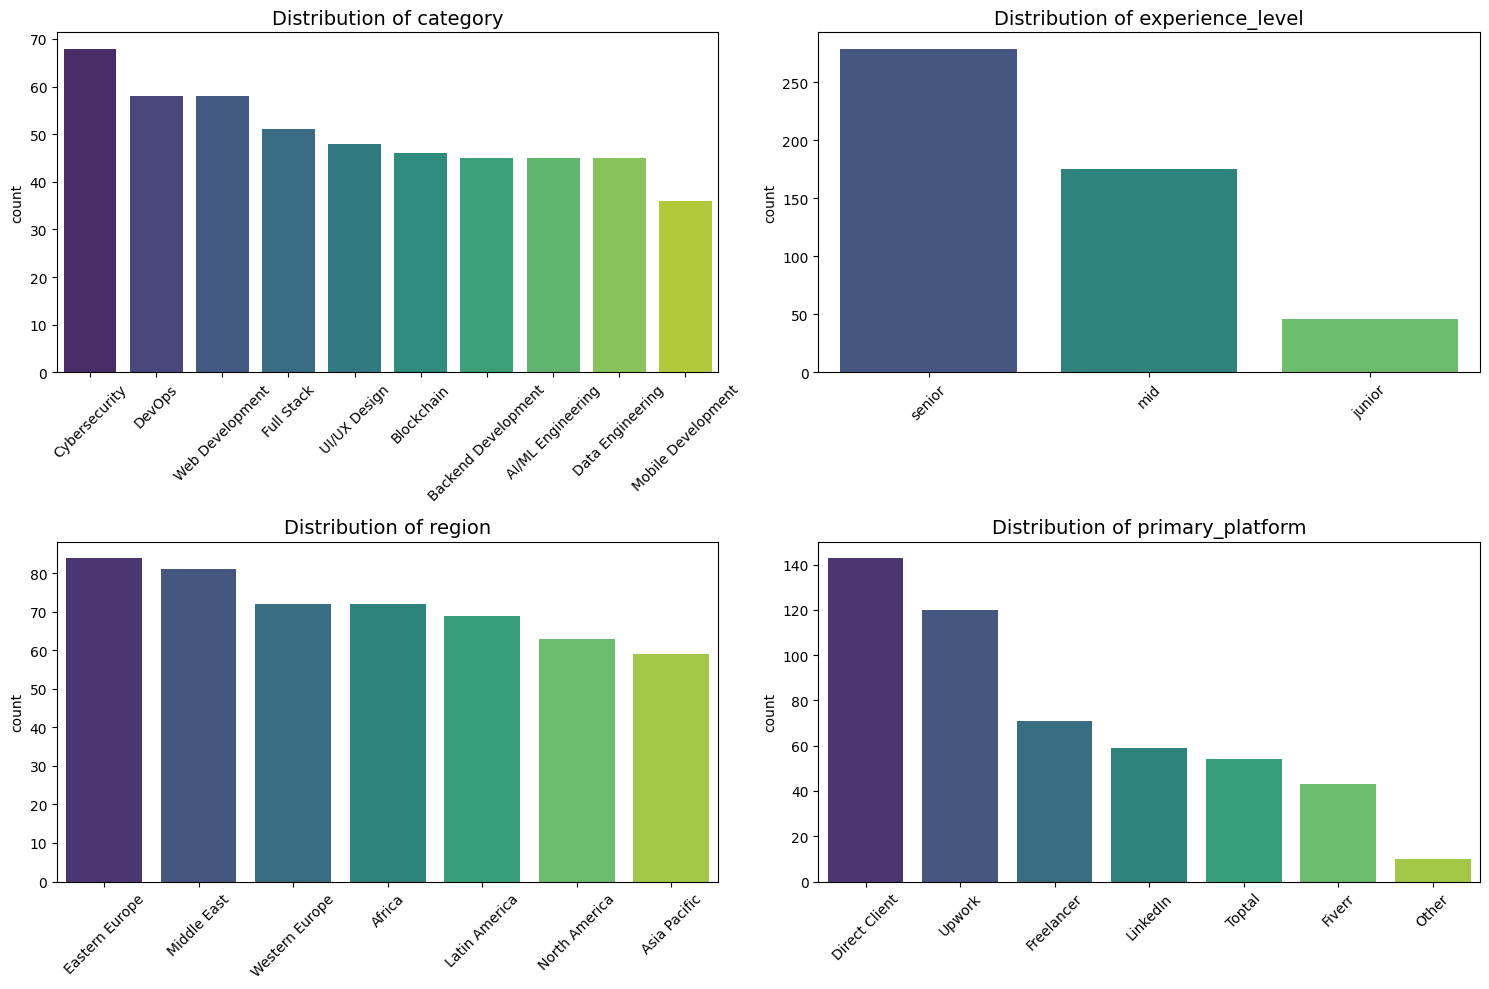

In [10]:
cat_cols = ['category', 'experience_level', 'region', 'primary_platform']

# Create a 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', 
                  order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('') # Remove x-label to clean up space

plt.tight_layout()
plt.show()

## 4.2 Analyze Numerical Columns
Distribution of `annual_income_usd`, `hourly_rate_usd`, `years_experience`

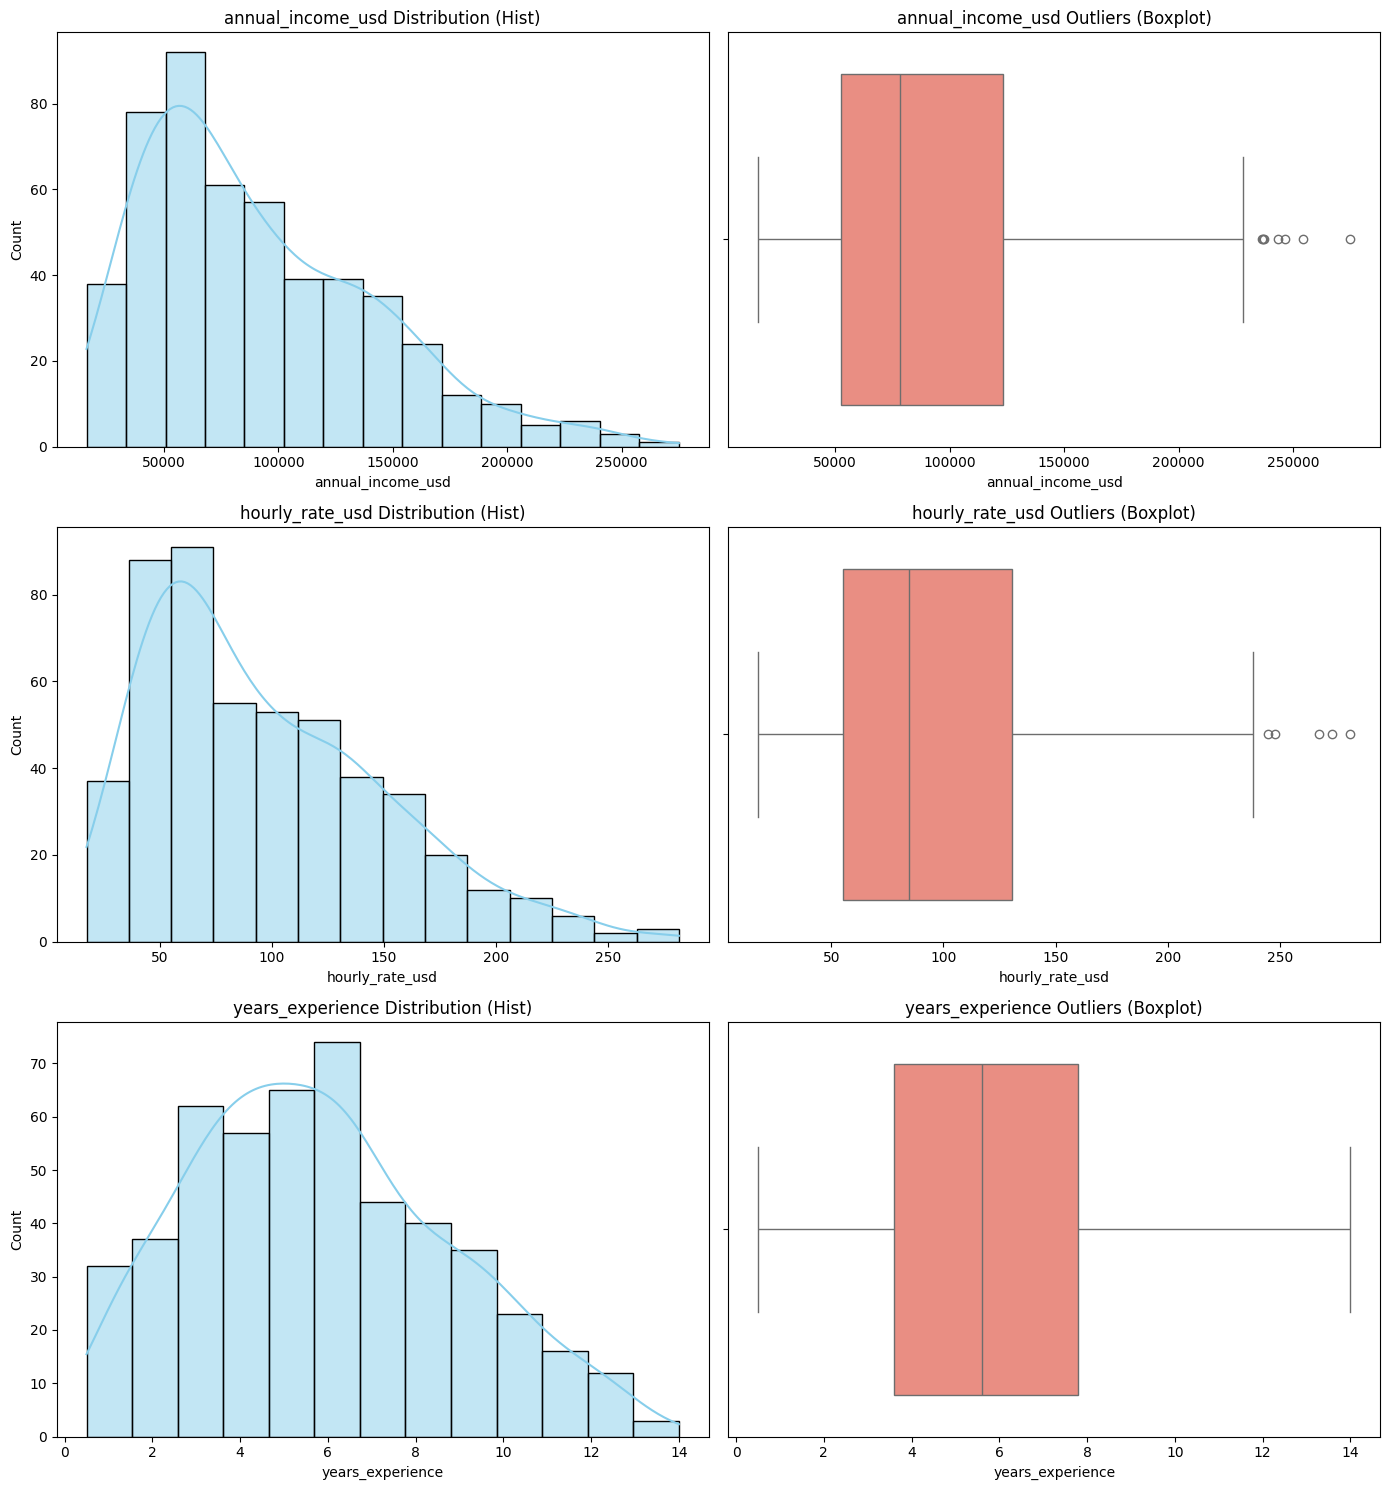

In [11]:
# Define columns
num_cols = ['annual_income_usd', 'hourly_rate_usd', 'years_experience']

# Create a 3x2 grid (3 variables, 2 chart types each)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))

for i, col in enumerate(num_cols):
    # Column 0: Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} Distribution (Hist)', fontsize=12)
    
    # Column 1: Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'{col} Outliers (Boxplot)', fontsize=12)

plt.tight_layout()
plt.show()

# Step 5: Bivariate Analysis

## 5.1 Category vs Annual Income
 Compare average income across categories.


/tmp/ipykernel_17/412980526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='category', y='annual_income_usd', palette='magma', order=order)


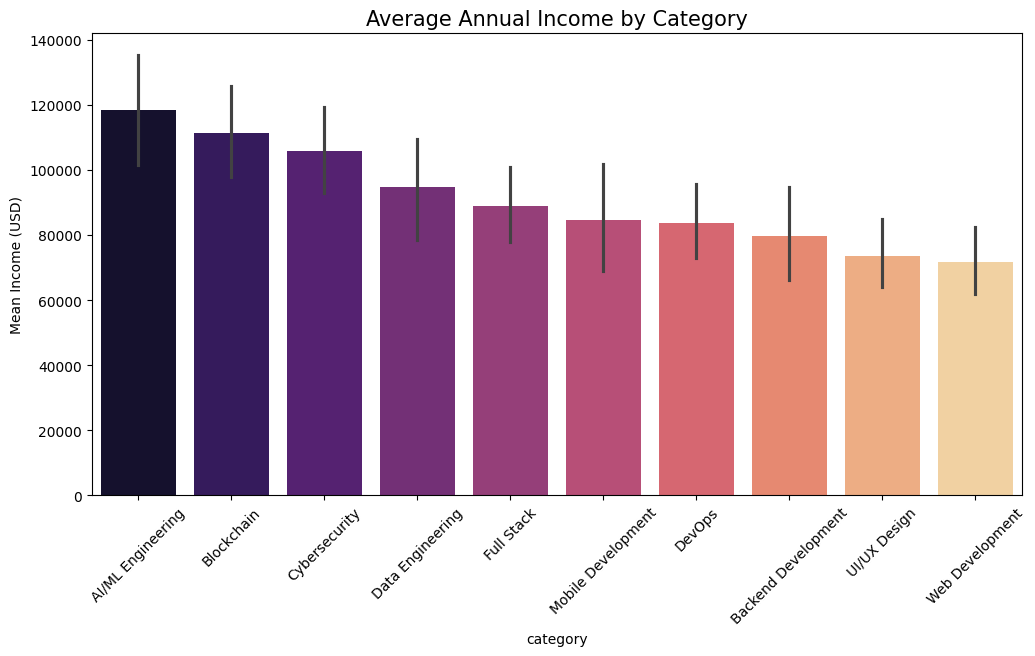

In [12]:
plt.figure(figsize=(12, 6))

# Calculating the mean for sorting
order = df.groupby('category')['annual_income_usd'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='category', y='annual_income_usd', palette='magma', order=order)
plt.title('Average Annual Income by Category', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Mean Income (USD)')
plt.show()

## 5.2 Experience Level vs Income 
How junior/mid/senior levels affect income.

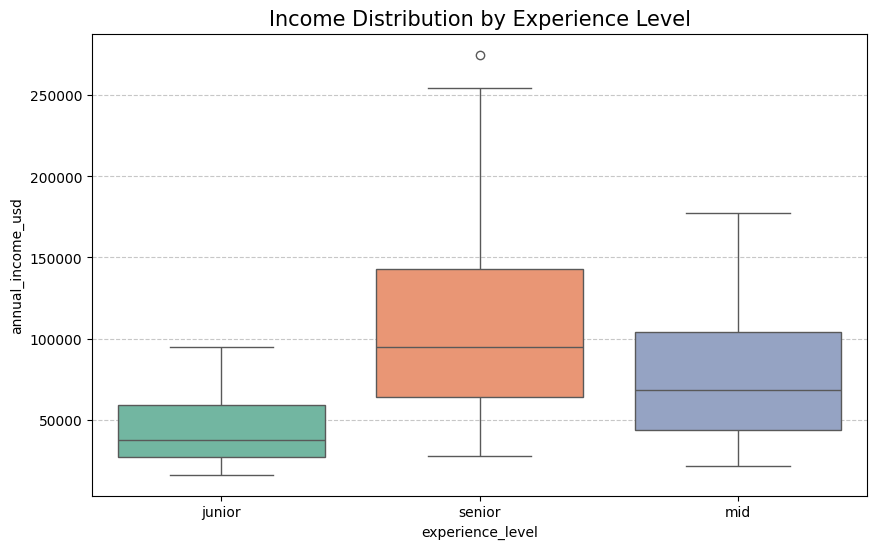

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='experience_level', 
    y='annual_income_usd', 
    hue='experience_level',
    palette='Set2',        
)

plt.title('Income Distribution by Experience Level', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5.3 Skills vs Hourly Rate

Identify skill sets linked to higher pay.

/tmp/ipykernel_17/3388669200.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')


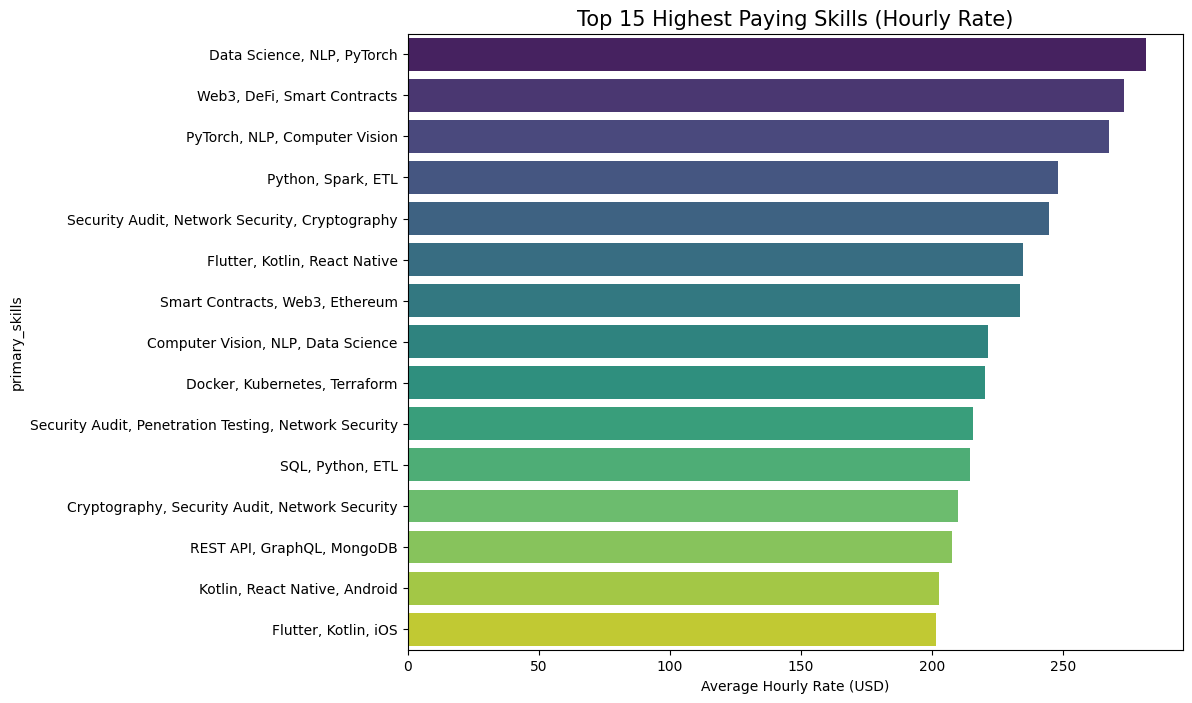

In [14]:
plt.figure(figsize=(10, 8))

top_skills = df.groupby('primary_skills')['hourly_rate_usd'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')
plt.title('Top 15 Highest Paying Skills (Hourly Rate)', fontsize=15)
plt.xlabel('Average Hourly Rate (USD)')
plt.show()

# Step 6: Multivariate Analysis



## 6.1 Category + Experience + Income 
Combine multiple variables to see patterns.


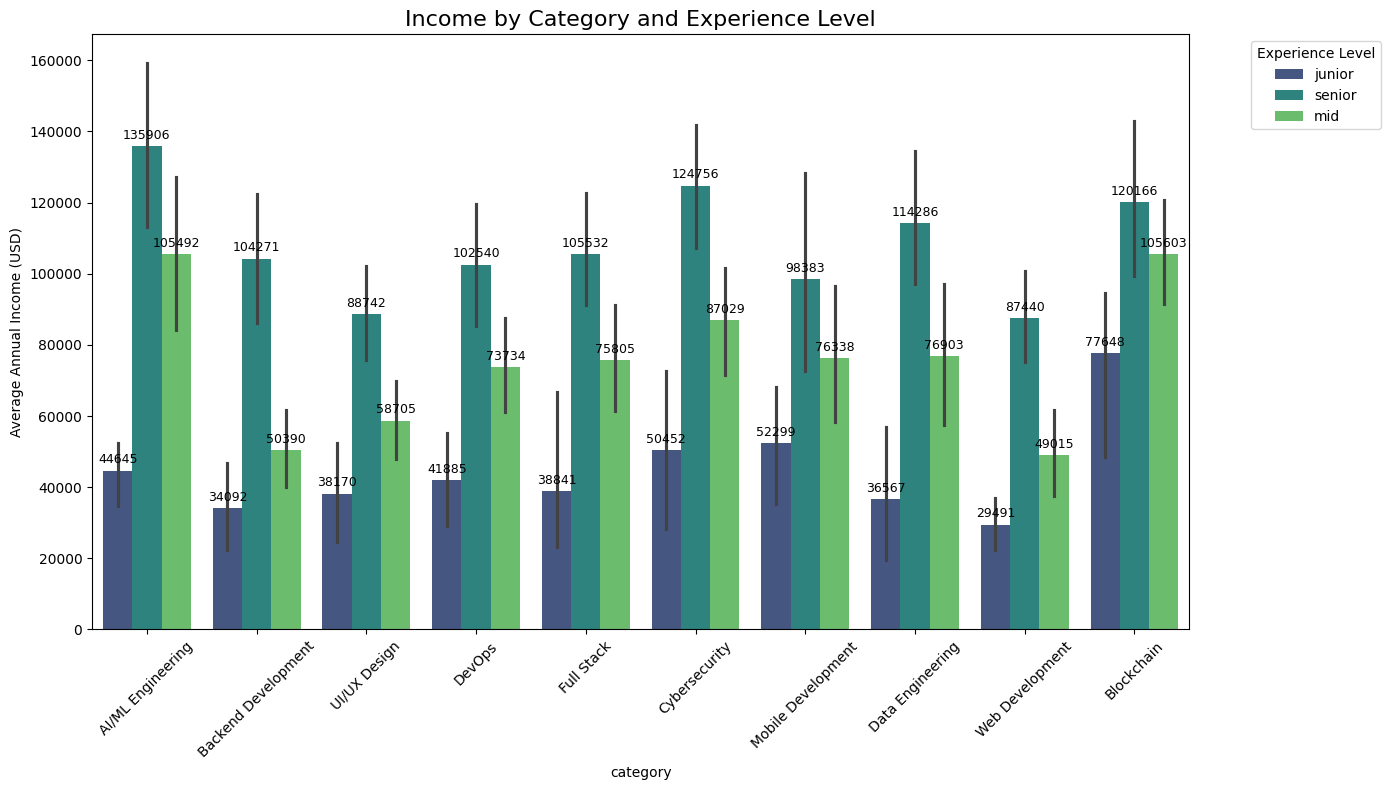

               category experience_level  annual_income_usd
2     AI/ML Engineering           senior      135905.872593
11        Cybersecurity           senior      124755.603947
8            Blockchain           senior      120166.263333
14     Data Engineering           senior      114285.815769
7            Blockchain              mid      105602.890526
20           Full Stack           senior      105531.610769
1     AI/ML Engineering              mid      105491.980000
5   Backend Development           senior      104271.201538
17               DevOps           senior      102539.943571
23   Mobile Development           senior       98382.779474
26         UI/UX Design           senior       88742.282143
29      Web Development           senior       87440.007297
10        Cybersecurity              mid       87028.590385
6            Blockchain           junior       77648.096667
13     Data Engineering              mid       76903.355333
22   Mobile Development              mid

In [15]:
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=df, 
    x='category', 
    y='annual_income_usd', 
    hue='experience_level',
    # hue_order=exp_order,
    palette='viridis'
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

# ---- CALCULATE MEANS ----
mean_df = (
    df.groupby(['category', 'experience_level'])['annual_income_usd']
      .mean()
      .reset_index().sort_values(by= 'annual_income_usd',ascending=False)
)

plt.title('Income by Category and Experience Level', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Average Annual Income (USD)')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print(mean_df)


## 6.2 Region + Platform + Income 
Understand geographic and platform influence on earnings.

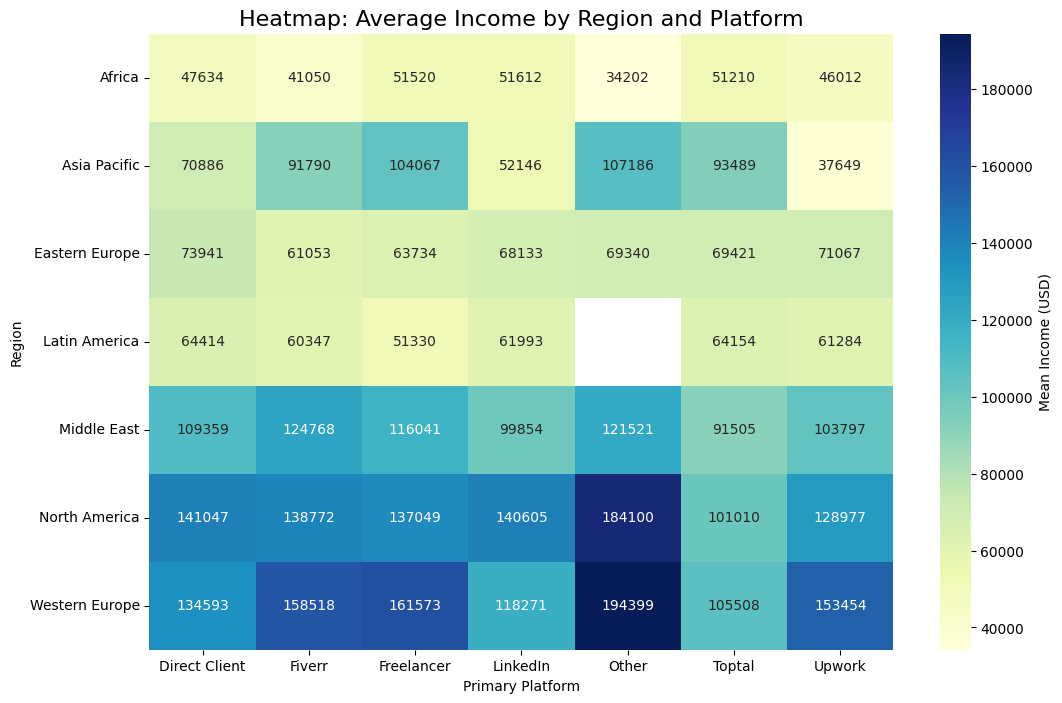

In [16]:
# Create a pivot table of the average income
pivot_table = df.pivot_table(
    values='annual_income_usd', 
    index='region', 
    columns='primary_platform', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Mean Income (USD)'})

plt.title('Heatmap: Average Income by Region and Platform', fontsize=16)
plt.xlabel('Primary Platform')
plt.ylabel('Region')
plt.show()

# Step 7: Platform & Region Analysis
## 7.1 Platform vs Annual Income

Goal: Compare average earnings across freelancing platforms

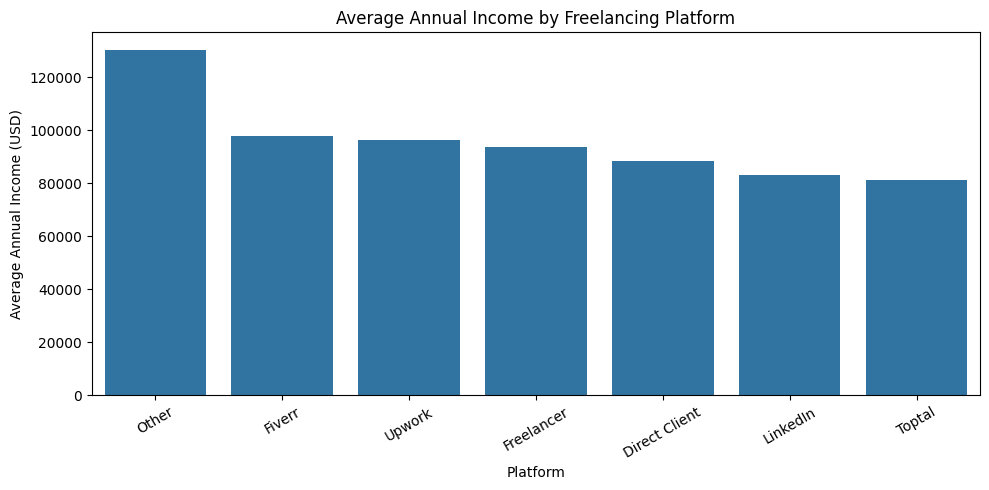

In [17]:
# Average annual income by platform
platform_income = (
    df.groupby('primary_platform')['annual_income_usd']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='primary_platform',
    y='annual_income_usd',
    data=platform_income
)

plt.title('Average Annual Income by Freelancing Platform')
plt.xlabel('Platform')
plt.ylabel('Average Annual Income (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 7.2 Region vs Annual Income


 Goal: Compare freelancer income across regions (continents)

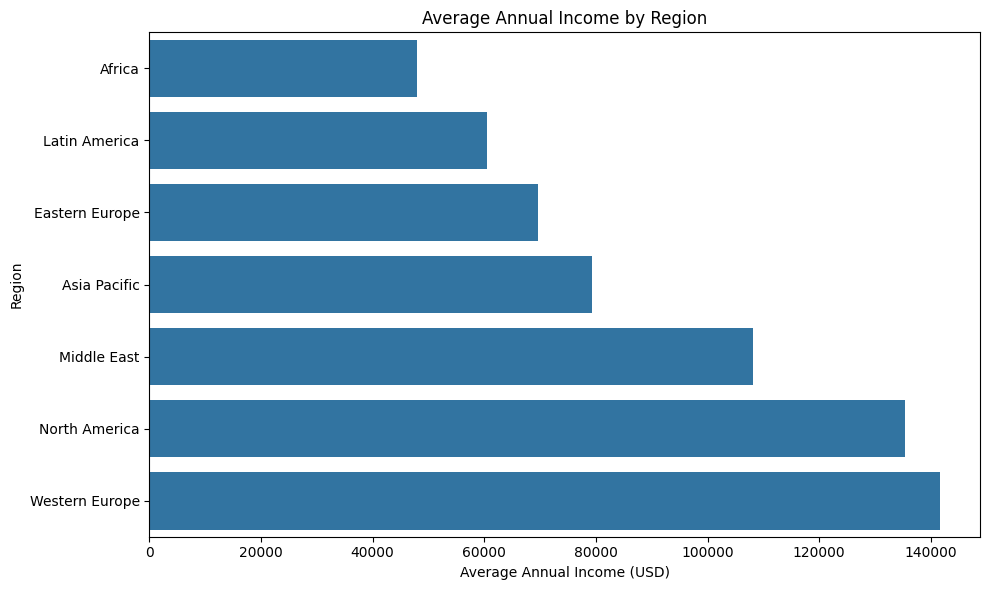

In [18]:
# Average annual income by region
region_income = (
    df.groupby('region')['annual_income_usd']
      .mean()
      .sort_values()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    y='region',
    x='annual_income_usd',
    data=region_income
)

plt.title('Average Annual Income by Region')
plt.xlabel('Average Annual Income (USD)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


# 🌟📊 **Data Driven Question Answering** 📊🌟
## Q1.Which freelancer categories earn the highest average annual income?

/tmp/ipykernel_17/2030408212.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_17/2030408212.py:26: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


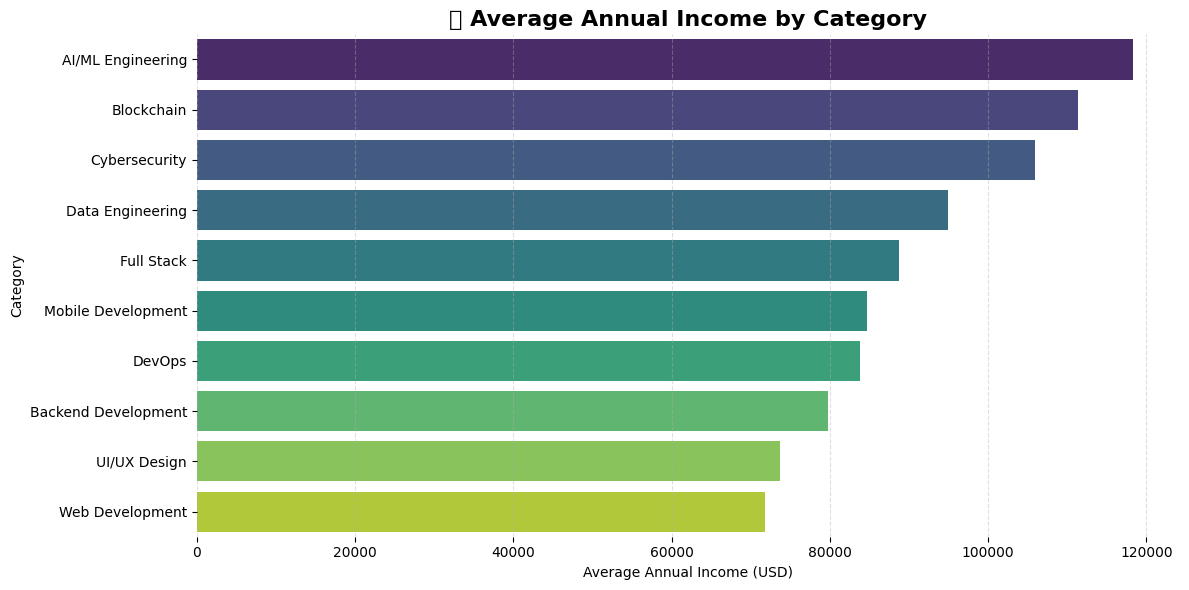

,category,annual_income_usd
0,AI/ML Engineering,118331.673556
2,Blockchain,111378.033261
3,Cybersecurity,105959.757794
4,Data Engineering,94916.688667
6,Full Stack,88785.315490
7,Mobile Development,84633.925556
5,DevOps,83796.328103
1,Backend Development,79710.401556
8,UI/UX Design,73659.954792
9,Web Development,71844.473276


In [19]:
# Aggregate & sort data
group_income_category = (
    df.groupby('category', as_index=False)['annual_income_usd']
      .mean()
      .sort_values(by='annual_income_usd', ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=group_income_category,
    x='annual_income_usd',
    y='category',
    palette='viridis'
)


# Styling
plt.title('💰 Average Annual Income by Category', fontsize=16, weight='bold')
plt.xlabel('Average Annual Income (USD)')
plt.ylabel('Category')

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

group_income_category


## Answer:
### 💰 Highest Earning Freelancer Categories

Based on the data, the freelancer categories with the highest **average annual income** are:

1. **AI/ML Engineering** – \$118,332  
2. **Blockchain** – \$111,378  
3. **Cybersecurity** – \$105,960  

These categories lead the list, indicating that specialized technical skills in emerging technologies tend to command higher earnings compared to other categories like Web Development or UI/UX Design.


## Q2. Which primary skills are most associated with higher hourly rates?

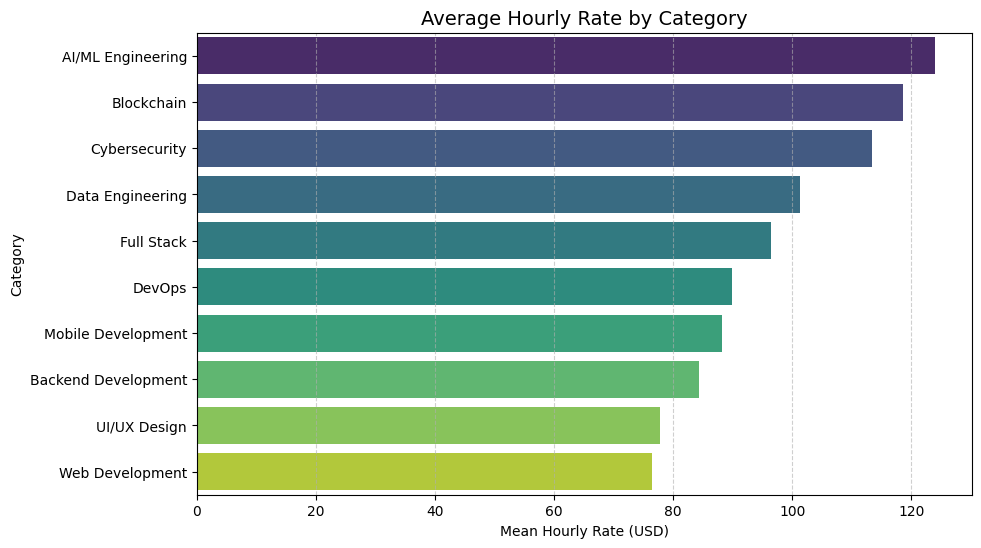

,category,hourly_rate_usd
0,AI/ML Engineering,123.963111
2,Blockchain,118.647174
3,Cybersecurity,113.345147
4,Data Engineering,101.255778
6,Full Stack,96.452549
5,DevOps,89.887586
7,Mobile Development,88.255278
1,Backend Development,84.388667
8,UI/UX Design,77.747500
9,Web Development,76.477586


In [20]:
category_hourly_rate = (
    df.groupby('category', as_index=False)['hourly_rate_usd']
    .mean()
    .sort_values(by='hourly_rate_usd', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='hourly_rate_usd', 
    y='category', 
    data=category_hourly_rate, 
    hue='category',     
    palette='viridis',  
    legend=False     
)

plt.title('Average Hourly Rate by Category', fontsize=14)
plt.xlabel('Mean Hourly Rate (USD)')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.6) # Add gridlines for readability

plt.show()

# Display the dataframe as well
category_hourly_rate

## Answer:
### 💸 Freelancer Categories with the Highest Hourly Rates

The data shows that freelancers with specialized technical skills tend to earn higher **hourly rates**. The top categories are:

1. **AI/ML Engineering** – \$123.96/hr  
2. **Blockchain** – \$118.65/hr  
3. **Cybersecurity** – \$113.35/hr  

This suggests that expertise in advanced technologies and emerging fields is highly valued in the freelance market, resulting in higher pay per hour compared to categories like Web Development or UI/UX Design.


## Q3. How does annual income vary across experience levels (junior, mid, senior)?

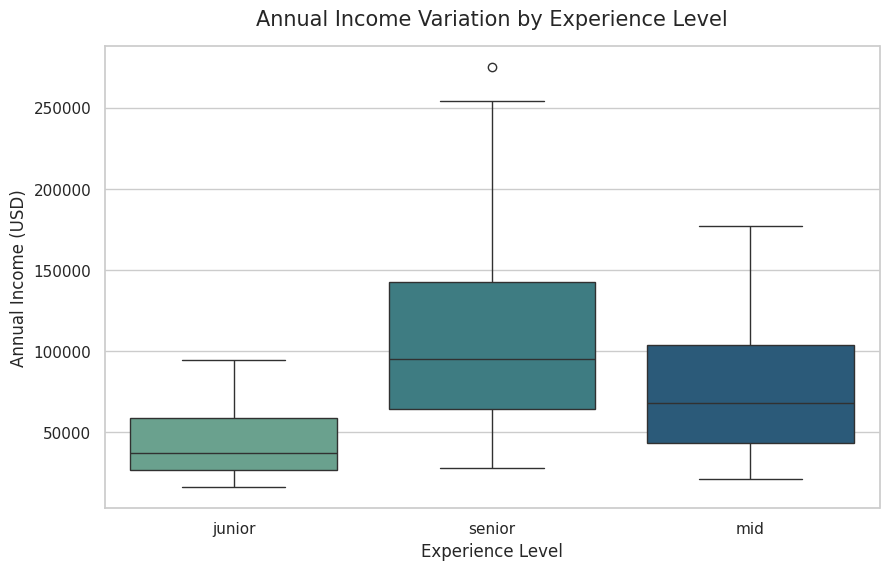

  experience_level  annual_income_usd
2           senior      108175.346093
1              mid       77090.544114
0           junior       42994.508043


In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))



sns.boxplot(
    data=df, 
    x='experience_level', 
    y='annual_income_usd',
    hue='experience_level',  
    palette='crest',     
    legend=False
)

# 4. Add labels and title
plt.title('Annual Income Variation by Experience Level', fontsize=15, pad=15)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Annual Income (USD)', fontsize=12)



plt.show()
print(df.groupby('experience_level', as_index=False)['annual_income_usd'].mean().sort_values(by='annual_income_usd', ascending=False))

## Answer:
### 📊 Annual Income by Experience Level

The average annual income varies significantly depending on experience:

- **Senior** – \$108,175  
- **Mid-Level** – \$77,091  
- **Junior** – \$42,995  

**Insight:** There is a clear positive relationship between experience and earnings. **Senior freelancers earn more than twice as much as juniors**, highlighting the value of experience and expertise in commanding higher rates in the freelance market.


## Q4. Is there a positive relationship between years of experience and hourly rate?

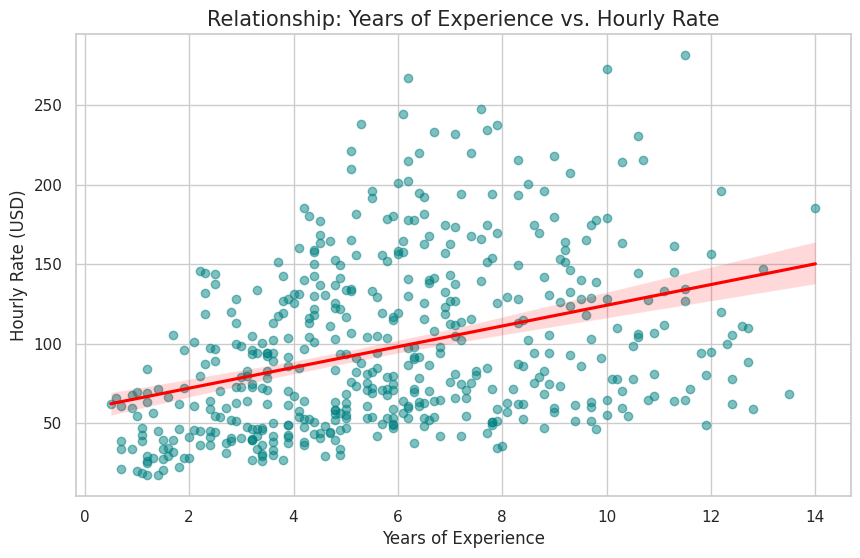

Correlation Coefficient: 0.36


In [22]:
plt.figure(figsize=(10, 6))

# Create a scatter plot with a regression line
sns.regplot(
    data=df, 
    x='years_experience', 
    y='hourly_rate_usd',
    scatter_kws={'alpha':0.5, 'color':'teal'}, # alpha makes dots transparent to see density
    line_kws={'color':'red'}                   # the trend line
)

plt.title('Relationship: Years of Experience vs. Hourly Rate', fontsize=15)
plt.xlabel('Years of Experience')
plt.ylabel('Hourly Rate (USD)')

plt.show()

# Calculate the Correlation Coefficient (Pearson)
correlation = df['years_experience'].corr(df['hourly_rate_usd'])
print(f"Correlation Coefficient: {correlation:.2f}")

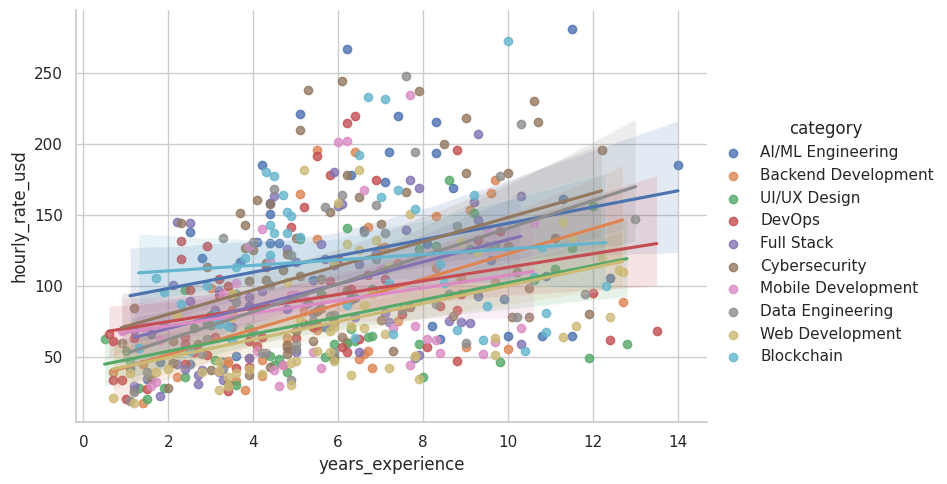

In [23]:
# Creates separate trend lines for each category
sns.lmplot(
    data=df, 
    x='years_experience', 
    y='hourly_rate_usd', 
    hue='category', 
    aspect=1.5
)

plt.show()

## Answer:
### 📈 Relationship Between Experience and Hourly Rate

The correlation coefficient between **years of experience** and **hourly rate** is **0.36**, indicating a **moderate positive relationship**.  

This means that, in general, freelancers with more experience tend to charge higher hourly rates, although other factors (such as skill specialization or demand) also influence earnings.


## Q5. Do freelancers with formal education (Bachelor/Master) earn more than self-taught or bootcamp graduates?

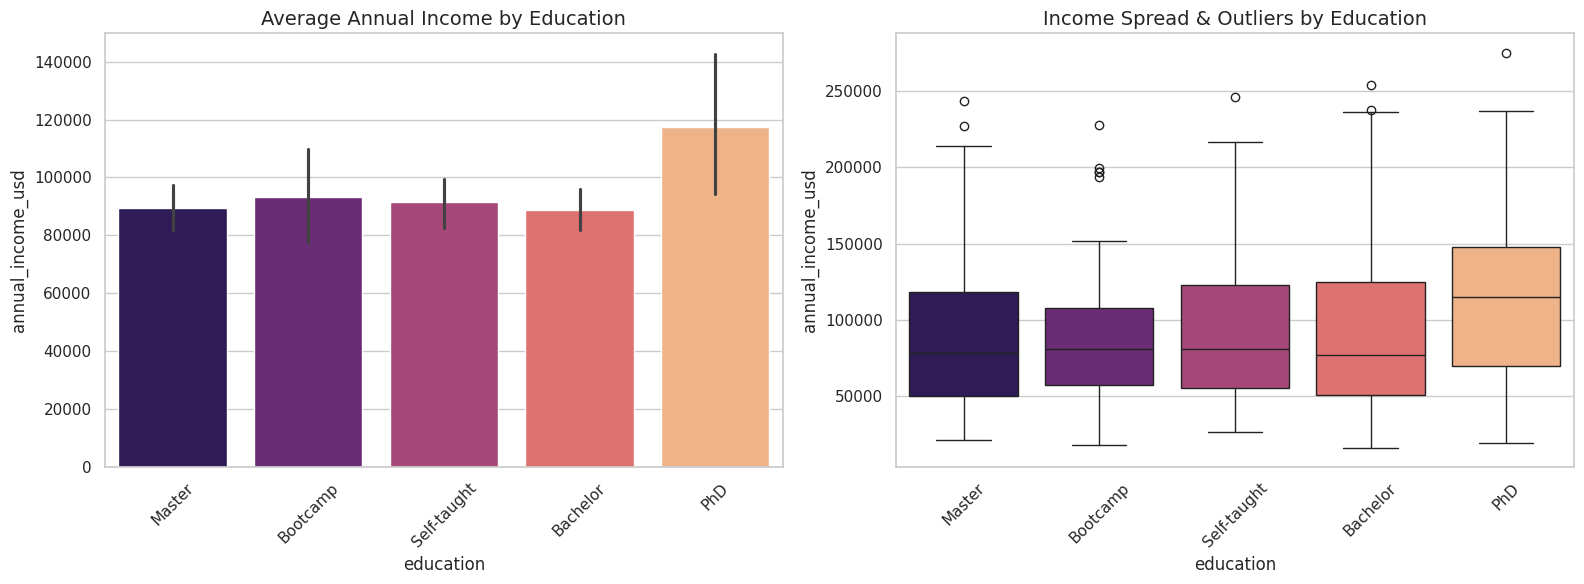

,mean,median,count
education,,,
PhD,"$117,265.55","$114,877.03",24
Bootcamp,"$93,105.96","$81,046.79",38
Self-taught,"$91,424.73","$81,130.92",112
Master,"$89,589.41","$78,234.60",139
Bachelor,"$88,794.74","$76,787.41",187


In [24]:
#  Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar Plot (Average Income)
sns.barplot(
    data=df, 
    x='education', 
    y='annual_income_usd', 
    palette='magma', 
    ax=axes[0],
    hue='education',
    legend=False
)
axes[0].set_title('Average Annual Income by Education', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: Box Plot (Distribution & Outliers)
sns.boxplot(
    data=df, 
    x='education', 
    y='annual_income_usd', 
    palette='magma', 
    ax=axes[1],
    hue='education',
    legend=False
)
axes[1].set_title('Income Spread & Outliers by Education', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table with multiple statistics
summary_table = df.groupby('education')['annual_income_usd'].agg(['mean', 'median', 'count'])

# Sort by mean income descending
summary_table = summary_table.sort_values(by='mean', ascending=False)

# Format the numbers for readability (adds $ and commas)
summary_table.style.format({
    'mean': '${:,.2f}',
    'median': '${:,.2f}',
    'count': '{:,}'
})

## Answer:
### 🎓 Impact of Education on Freelancer Earnings

The data shows the average annual income based on education level:

- **PhD** – Mean: \$117,266 | Median: \$114,877 | Count: 24  
- **Bootcamp** – Mean: \$93,106 | Median: \$81,047 | Count: 38  
- **Self-taught** – Mean: \$91,425 | Median: \$81,131 | Count: 112  
- **Master** – Mean: \$89,589 | Median: \$78,235 | Count: 139  
- **Bachelor** – Mean: \$88,795 | Median: \$76,787 | Count: 187  

**Insight:** Freelancers with higher formal education (PhD) earn significantly more on average. However, freelancers with Bachelor’s or Master’s degrees earn slightly less than those who attended Bootcamps or are self-taught. This suggests that **practical skills and specialized knowledge can sometimes outweigh formal education** in the freelance market.


## Q6. How does freelancer income differ across regions (North America, Middle East, Latin America)?

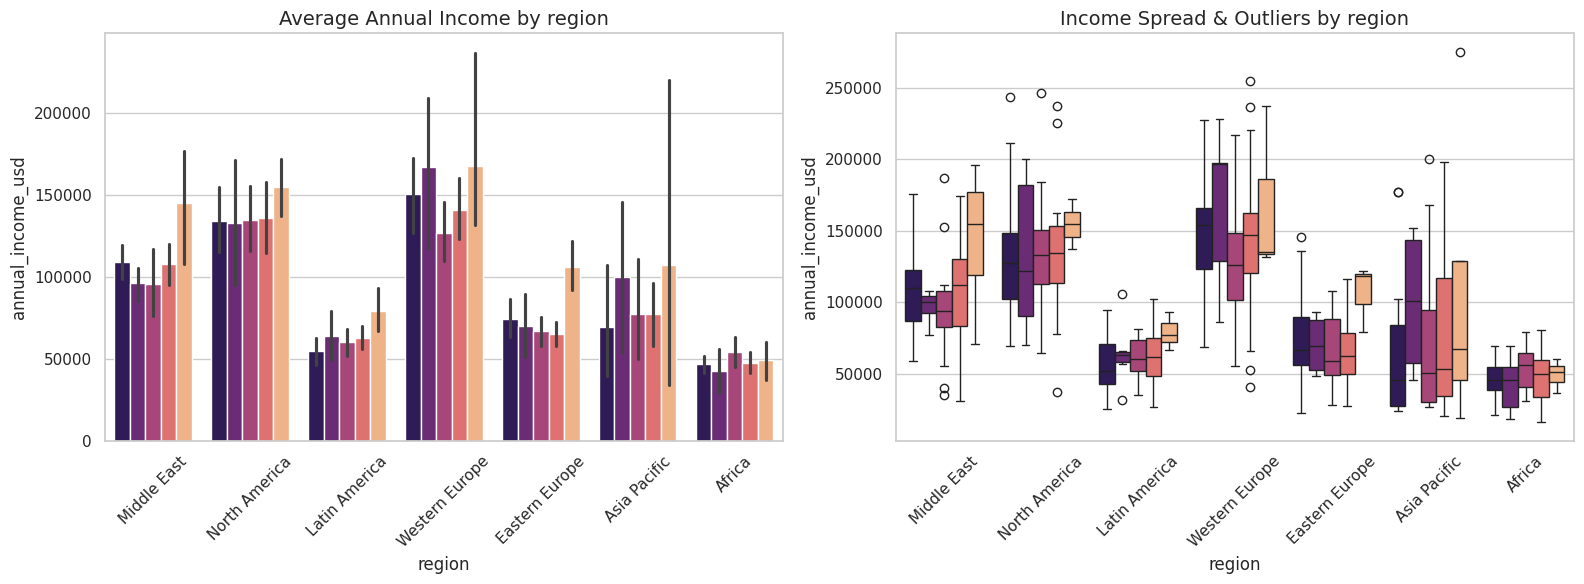

,mean,median,count
region,,,
Western Europe,"$141,714.75","$139,414.86",72
North America,"$135,359.13","$134,532.39",63
Middle East,"$108,134.84","$107,695.55",81
Asia Pacific,"$79,317.33","$53,654.15",59
Eastern Europe,"$69,632.14","$64,094.75",84
Latin America,"$60,526.49","$61,521.90",69
Africa,"$47,977.16","$46,066.24",72


In [25]:
#  Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar Plot (Average Income)
sns.barplot(
    data=df, 
    x='region', 
    y='annual_income_usd', 
    palette='magma', 
    ax=axes[0],
    hue='education',
    legend=False
)
axes[0].set_title('Average Annual Income by region', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: Box Plot (Distribution & Outliers)
sns.boxplot(
    data=df, 
    x='region', 
    y='annual_income_usd', 
    palette='magma', 
    ax=axes[1],
    hue='education',
    legend=False
)
axes[1].set_title('Income Spread & Outliers by region', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table with multiple statistics
summary_table = df.groupby('region')['annual_income_usd'].agg(['mean', 'median', 'count'])

# Sort by mean income descending
summary_table = summary_table.sort_values(by='mean', ascending=False)

# Format the numbers for readability (adds $ and commas)
summary_table.style.format({
    'mean': '${:,.2f}',
    'median': '${:,.2f}',
    'count': '{:,}'
})

## Answer:
### 🌍 Freelancer Income Across Different Regions

The average annual income of freelancers varies significantly by region:

- **Western Europe** – Mean: \$141,715 | Median: \$139,415 | Count: 72  
- **North America** – Mean: \$135,359 | Median: \$134,532 | Count: 63  
- **Middle East** – Mean: \$108,135 | Median: \$107,696 | Count: 81  
- **Asia Pacific** – Mean: \$79,317 | Median: \$53,654 | Count: 59  
- **Eastern Europe** – Mean: \$69,632 | Median: \$64,095 | Count: 84  
- **Latin America** – Mean: \$60,526 | Median: \$61,522 | Count: 69  
- **Africa** – Mean: \$47,977 | Median: \$46,066 | Count: 72  

**Insight:** Freelancers in **Western Europe** and **North America** earn the highest incomes, while those in **Latin America** and **Africa** earn significantly less. Regional economic conditions, demand for skills, and cost of living likely influence these differences.


## Q7. Which countries have the highest average hourly rates among freelancers?

Top 10 Countries with Highest Average Hourly Rates:
       country  hourly_rate_usd
0  Switzerland       176.010476
1    Australia       167.460714
2           US       155.643333
3      Germany       147.945000
4           UK       147.714706
5       France       127.417143
6        Japan       126.823750
7       Canada       120.187083
8       Israel       118.839048
9          UAE       112.096154


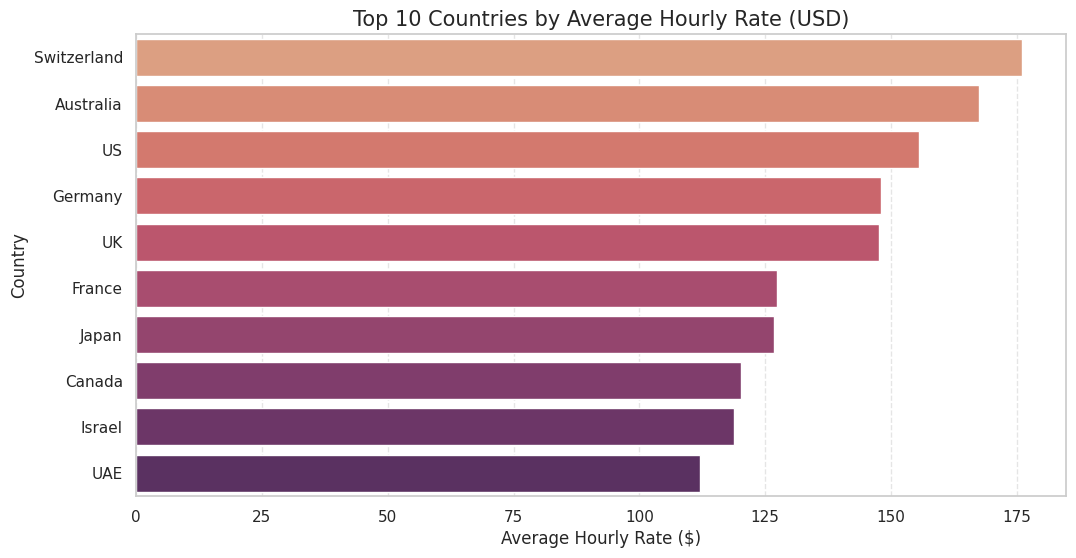

In [26]:
# 1. Group by Country and calculate the mean hourly rate
country_rates = (
    df.groupby('country')['hourly_rate_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10) # Get the top 10
    .reset_index()
)

# 2. Display the table
print("Top 10 Countries with Highest Average Hourly Rates:")
print(country_rates)

# 3. Visualization for a report
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=country_rates, 
    x='hourly_rate_usd', 
    y='country', 
    hue='country', 
    palette='flare', 
    legend=False
)

plt.title('Top 10 Countries by Average Hourly Rate (USD)', fontsize=15)
plt.xlabel('Average Hourly Rate ($)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Answer:
### 🌐 Countries with the Highest Freelancer Hourly Rates

The top countries where freelancers charge the highest **average hourly rates** are:

1. **Switzerland** – \$176.01/hr  
2. **Australia** – \$167.46/hr  
3. **United States** – \$155.64/hr  
4. **Germany** – \$147.95/hr  
5. **United Kingdom** – \$147.71/hr  
6. **France** – \$127.42/hr  
7. **Japan** – \$126.82/hr  
8. **Canada** – \$120.19/hr  
9. **Israel** – \$118.84/hr  
10. **UAE** – \$112.10/hr  

**Insight:** Freelancers in **Switzerland, Australia, and the US** command the highest rates, reflecting strong demand for skilled professionals and higher living costs in these countries.


## Q8. Which freelancing platforms (Upwork, Freelancer, Direct Client, LinkedIn) generate higher annual income?

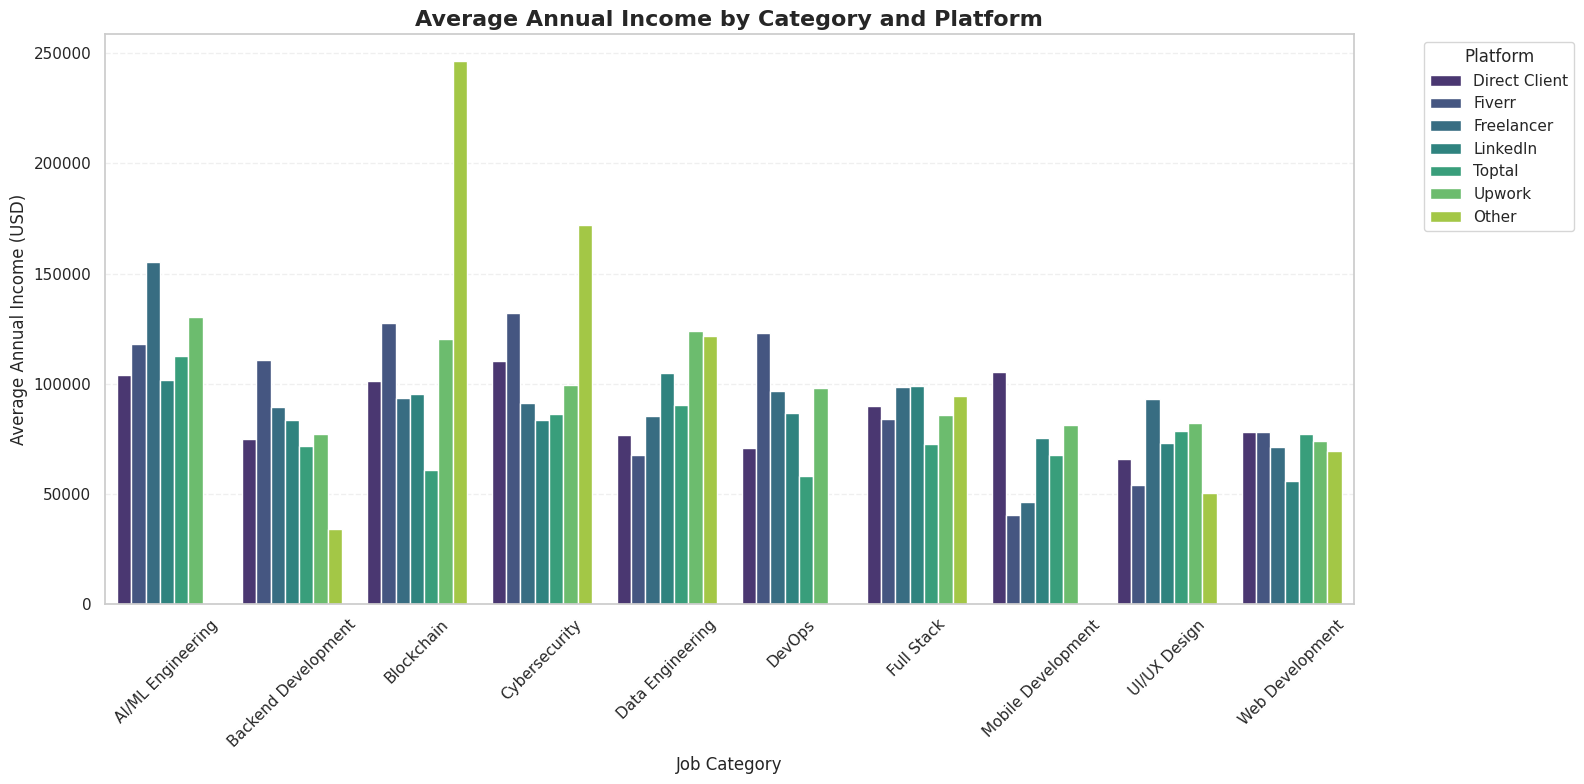

,category,primary_platform,annual_income_usd
0,AI/ML Engineering,Direct Client,103821.670769
1,AI/ML Engineering,Fiverr,118158.003333
2,AI/ML Engineering,Freelancer,155450.425714
3,AI/ML Engineering,LinkedIn,101447.083333
4,AI/ML Engineering,Toptal,112474.005556
...,...,...,...
62,Web Development,Freelancer,71019.295833
63,Web Development,LinkedIn,55579.221111
64,Web Development,Other,69340.020000
65,Web Development,Toptal,77311.145714


In [27]:
# 1. Prepare the data: Calculate average income per category and platform
platform_cat_income = (
    df.groupby(['category', 'primary_platform'])['annual_income_usd']
    .mean()
    .reset_index()
)

# 2. Set the visual style
plt.figure(figsize=(16, 8))

# 3. Create the Grouped Bar Plot
sns.barplot(
    data=platform_cat_income, 
    x='category', 
    y='annual_income_usd', 
    hue='primary_platform', 
    palette='viridis'
)

# 4. Final Polish
plt.title('Average Annual Income by Category and Platform', fontsize=16, fontweight='bold')
plt.ylabel('Average Annual Income (USD)', fontsize=12)
plt.xlabel('Job Category', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
platform_cat_income

## Answer:
### 💻 Freelancing Platforms and Annual Income

The data indicates how the **primary platform** affects average annual income for freelancers:

- **Freelancer** – Often yields the **highest income**, e.g., AI/ML Engineering: \$155,450  
- **Fiverr** – High-paying for specialized skills, e.g., AI/ML Engineering: \$118,158  
- **Toptal** – Provides premium opportunities, e.g., AI/ML Engineering: \$112,474  
- **Direct Client** – Competitive, e.g., AI/ML Engineering: \$103,822  
- **LinkedIn** – Moderate earnings, e.g., AI/ML Engineering: \$101,447  
- **Upwork** – Varies by category but generally mid-range, e.g., Web Development: \$74,133  

**Insight:** Freelancers working through **Freelancer and Fiverr** tend to earn higher annual incomes, especially in high-demand categories like AI/ML Engineering. Platforms that connect directly to clients or focus on premium talent (Toptal) also provide strong earning opportunities.


<div style="font-family: 'Arial', sans-serif; max-width: 800px; margin: auto; padding: 20px; border: 2px solid #ddd; border-radius: 12px; background: #f9f9f9; text-align: center; box-shadow: 0 4px 10px rgba(0,0,0,0.1);">

  <h2 style="color:#2c3e50;">👍 If you found this analysis helpful, give it a vote!</h2>
  
  <p style="font-size:16px; color:#555;">
    📝 Notice any issue or want to explore further analysis?  
    Feel free to leave your feedback or suggestions.  
  </p>
  
  <div style="margin-top:20px;">
    <a href="#" style="text-decoration:none; padding:12px 25px; background-color:#16a085; color:white; font-weight:bold; border-radius:8px; margin-right:10px;">Vote 👍</a>
    <a href="#" style="text-decoration:none; padding:12px 25px; background-color:#e67e22; color:white; font-weight:bold; border-radius:8px;">Feedback ✍️</a>
  </div>

  <p style="font-size:14px; color:#999; margin-top:15px;">Your support and feedback help improve the analysis! 🌟</p>
</div>
